<a href="https://colab.research.google.com/github/mofermino/condensed-subject-matters/blob/main/phonons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ValueError: x and y must have same first dimension, but have shapes (300,) and (100,)

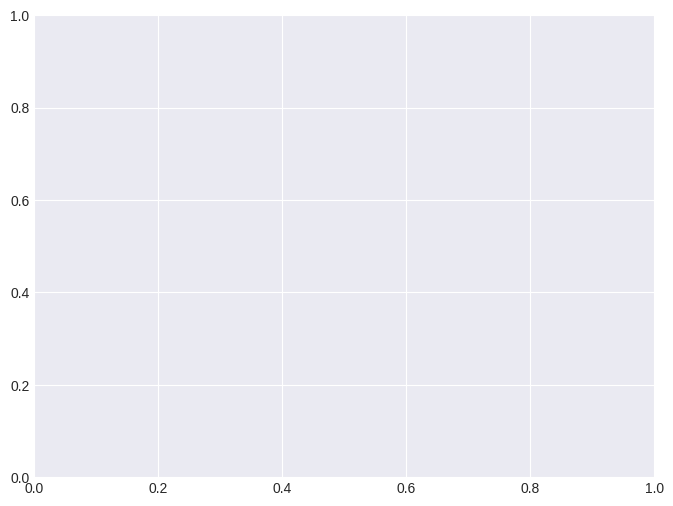

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#use vampire
def calculate_phonon_dispersion_2d_square():
    """
    Calculates and plots the phonon dispersion for a 2D monatomic square lattice.
    This is a simplified model using nearest-neighbor interactions (a "spring").
    """
    # --- 1. Define Simulation Parameters ---
    a = 1.0       # Lattice constant (arbitrary units)
    m = 1.0       # Atomic mass (arbitrary units)
    K = 1.0       # Spring constant (force constant, arbitrary units)

    # --- 2. Define the Brillouin Zone Path ---
    # Path: Gamma -> X -> M -> Gamma
    n_points = 100 # Number of k-points per segment

    # Coordinates of high-symmetry points
    gamma = np.array([0, 0])
    x = np.array([np.pi/a, 0])
    m_point = np.array([np.pi/a, np.pi/a])

    # Create the k-point paths
    k_path1 = np.linspace(gamma, x, n_points)         # Gamma to X
    k_path2 = np.linspace(x, m_point, n_points)       # X to M
    k_path3 = np.linspace(m_point, gamma, n_points)   # M to Gamma

    k_points = np.vstack([k_path1, k_path2, k_path3])

    # --- 3. Calculate Frequencies for each k-point ---
    frequencies = []
    for k in k_points:
        kx, ky = k[0], k[1]

        # Build the 2x2 Dynamical Matrix D(k)
        # For a simple 2D square lattice with one atom per cell and nearest-neighbor forces:
        D_xx = (2 * K / m) * (2 - np.cos(kx * a) - np.cos(ky * a/2))
        D_yy = D_xx # By symmetry
        D_xy = 0
        D_yx = 0

        Dynamical_Matrix = np.array([[D_xx, D_xy],
                                     [D_yx, D_yy]])

        # Solve the eigenvalue problem: eigenvalues are omega^2
        omega_squared_eigenvals = np.linalg.eigvalsh(Dynamical_Matrix)

        # Frequencies are the square root of the eigenvalues
        # Sort to ensure smooth plotting
        omegas = np.sqrt(np.sort(omega_squared_eigenvals))
        frequencies.append(omegas)

    frequencies = np.array(frequencies)

    # --- 4. Plot the Results ---
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(figsize=(8, 6))

    # X-axis for the plot
    x_axis = np.arange(len(k_points))

    # Plot the two branches (longitudinal and transverse acoustic modes)
    ax.plot(x_axis, frequencies[:, 0], label='Transverse Acoustic (TA)')
    ax.plot(x_axis, frequencies[:, 1], label='Longitudinal Acoustic (LA)')

    # Formatting the plot
    ax.set_ylabel(r'Frequency, $\omega$ [$\sqrt{K/m}$]', fontsize=14)
    ax.set_title('Phonon Dispersion of a 2D Square Lattice', fontsize=16)

    # Set the x-axis ticks to the high-symmetry points
    tick_locs = [0, n_points, 2 * n_points, 3 * n_points - 1]
    tick_labels = [r'$\Gamma$', 'X', 'M', r'$\Gamma$']
    ax.set_xticks(tick_locs)
    ax.set_xticklabels(tick_labels, fontsize=14)
    for loc in tick_locs:
        ax.axvline(x=loc, color='gray', linestyle='--', linewidth=0.8)

    ax.legend(fontsize=12)
    ax.set_xlim(0, len(k_points) - 1)
    ax.set_ylim(bottom=0)
    plt.show()

# Run the simulation
calculate_phonon_dispersion_2d_square()

/tmp/ipython-input-920628799.py:59: RuntimeWarning: invalid value encountered in sqrt
  omegas = np.sqrt(np.sort(omega_squared_eigenvals))


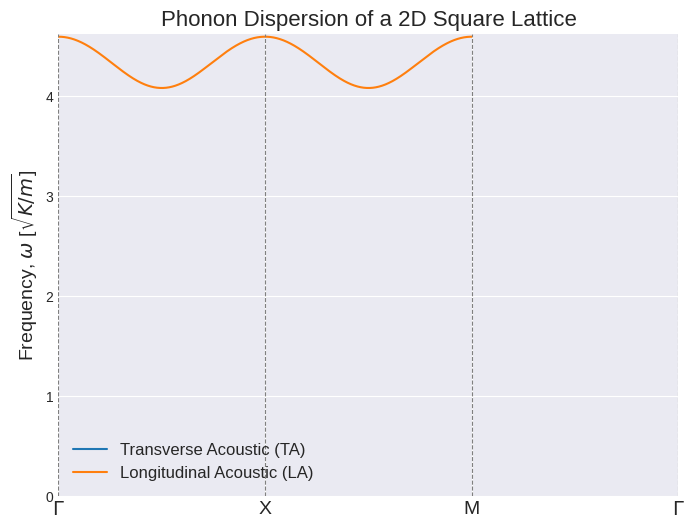

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_phonon_dispersion_2d_square():
    """
    Calculates and plots the phonon dispersion for a 2D monatomic square lattice.
    This is a simplified model using nearest-neighbor interactions (a "spring").
    """
    # --- 1. Define Simulation Parameters ---
    a = 0.4       # Lattice constant (arbitrary units)
    m = 0.9      # Atomic mass (arbitrary units)
    K = 1.0       # Spring constant (force constant, arbitrary units)

    # --- 2. Define the Brillouin Zone Path ---
    # Path: Gamma -> X -> M -> Gamma
    n_points = 1010 # Number of k-points per segment

    # Coordinates of high-symmetry points
    gamma = np.array([0, 0])
    x = np.array([np.pi/a, 0])
    m_point = np.array([np.pi/a, np.pi/a])
    d = np.array([0, np.pi/a])
    # Create the k-point paths
    k_path1 = np.linspace(gamma, x, n_points)         # Gamma to X
    k_path2 = np.linspace(x, m_point, n_points)       # X to M
    k_path3 = np.linspace(m_point, gamma, n_points)   # M to Gamma
    d_path = np.linspace(gamma, d, n_points)          # Gamma to d
    #c_path = np.linspace(d, gamma, n_points)          # d to Gamma
    f_path = np.array([-np.pi/a, np.pi/a])
    r_path = np.array([np.pi/a, np.pi/a])
    # Create the k-point paths
   # g_path = np.linspace(gamma, m_point, n_points)      # Gamma to m
    c_path = np.linspace(f_path, r_path, n_points)      # m to Gamma
    a_path = np.linspace(r_path, f_path, n_points)      # m to Gamma
    # Combine the paths
    k_points = np.vstack([k_path1, k_path2, k_path3])
    #d_points = np.vstack([d_path, c_path])
    c_points = np.vstack([a_path, c_path])
    # --- 3. Calculate Frequencies for each k-point ---
    frequencies = []
    for k in c_points:
        kx, ky = k[0], k[1]

        # Build the 2x2 Dynamical Matrix D(k)
        # For a simple 2D square lattice with one atom per cell and nearest-neighbor forces:
        D_xx = (2 * K / m) * (2 - np.cos(kx * a) - np.cos(ky * a))
        D_yy = D_xx # By symmetry
        D_xy = 8*K/ (m * m * m * m)
        D_yx = -8*K/ (m * m * m * m)

        Dynamical_Matrix = np.array([[D_xx, D_xy],
                                     [D_yx, D_yy]])

        # Solve the eigenvalue problem: eigenvalues are omega^2
        omega_squared_eigenvals = np.linalg.eigvalsh(Dynamical_Matrix)

        # Frequencies are the square root of the eigenvalues
        # Sort to ensure smooth plotting
        omegas = np.sqrt(np.sort(omega_squared_eigenvals))
        frequencies.append((omegas))

    frequencies = np.array(frequencies)

    # --- 4. Plot the Results ---
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(figsize=(8, 6))

    # X-axis for the plot
    x_axis = np.arange(len(c_points))

    # Plot the two branches (longitudinal and transverse acoustic modes)
    ax.plot(x_axis, frequencies[:, 0], label='Transverse Acoustic (TA)')
    ax.plot(x_axis, frequencies[:, 1], label='Longitudinal Acoustic (LA)')

    # Formatting the plot
    ax.set_ylabel(r'Frequency, $\omega$ [$\sqrt{K/m}$]', fontsize=14)
    ax.set_title('Phonon Dispersion of a 2D Square Lattice', fontsize=16)

    # Set the x-axis ticks to the high-symmetry points
    tick_locs = [0, n_points, 2 * n_points, 3 * n_points - 1]
    tick_labels = [r'$\Gamma$', 'X', 'M', r'$\Gamma$']
    ax.set_xticks(tick_locs)
    ax.set_xticklabels(tick_labels, fontsize=14)
    for loc in tick_locs:
        ax.axvline(x=loc, color='gray', linestyle='--', linewidth=0.8)

    ax.legend(fontsize=12)
    ax.set_xlim(0, len(k_points) - 1)
    ax.set_ylim(bottom=0)
    plt.show()

# Run the simulation
calculate_phonon_dispersion_2d_square()

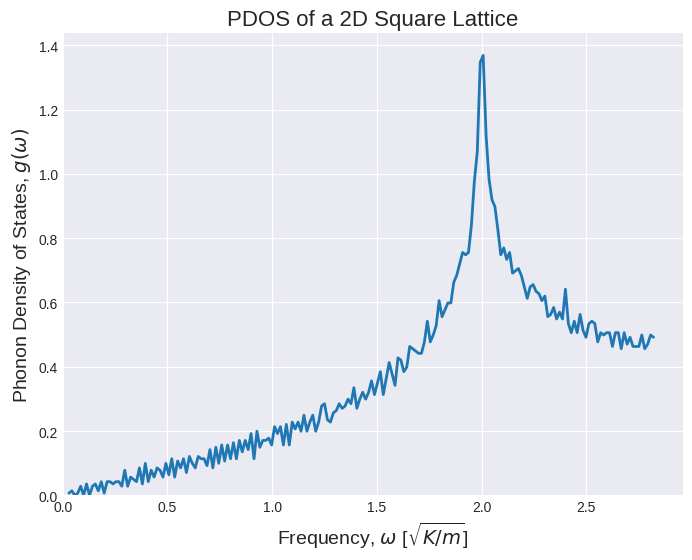

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_pdos_2d_square():
    """
    Calculates and plots the Phonon Density of States (PDOS) for a
    2D monatomic square lattice by sampling the full Brillouin Zone.
    """
    # --- 1. Define Simulation Parameters ---
    a = 1.0       # Lattice constant
    m = 1.0       # Atomic mass
    K = 1.0       # Spring constant

    # --- 2. Create a Uniform Grid of k-points in the Brillouin Zone ---
    # The first BZ for a 2D square lattice extends from -pi/a to +pi/a
    grid_size = 200  # Use a larger grid (e.g., 200x200) for a smoother curve
    kx_vals = np.linspace(-np.pi/a, np.pi/a, grid_size)
    ky_vals = np.linspace(-np.pi/a, np.pi/a, grid_size)

    all_frequencies = []

    # --- 3. Calculate Frequencies for each k-point on the grid ---
    for kx in kx_vals:
        for ky in ky_vals:
            # Build and solve the 2x2 Dynamical Matrix D(k)
            D_xx = (2 * K / m) * (2 - np.cos(kx * a) - np.cos(ky * a))
            D_yy = D_xx
            Dynamical_Matrix = np.array([[D_xx, 0], [0, D_yy]])

            omega_squared_eigenvals = np.linalg.eigvalsh(Dynamical_Matrix)

            # Add the positive real frequencies to our list
            # We take the absolute value to handle potential tiny negative numerical errors
            all_frequencies.extend(np.sqrt(np.abs(omega_squared_eigenvals)))

    # --- 4. Create and Plot the Histogram (PDOS) ---
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(figsize=(8, 6))

    # Use numpy's histogram function to get the density of states
    # The 'density=True' argument normalizes the histogram
    counts, bin_edges = np.histogram(all_frequencies, bins=200, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    ax.plot(bin_centers, counts, linewidth=2)

    # Formatting the plot
    ax.set_xlabel(r'Frequency, $\omega$ [$\sqrt{K/m}$]', fontsize=14)
    ax.set_ylabel(r'Phonon Density of States, $g(\omega)$', fontsize=14)
    ax.set_title('PDOS of a 2D Square Lattice', fontsize=16)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    plt.show()

# Run the simulation
calculate_pdos_2d_square()

/tmp/ipython-input-1123604472.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  cv = np.trapz(integrand, frequencies)


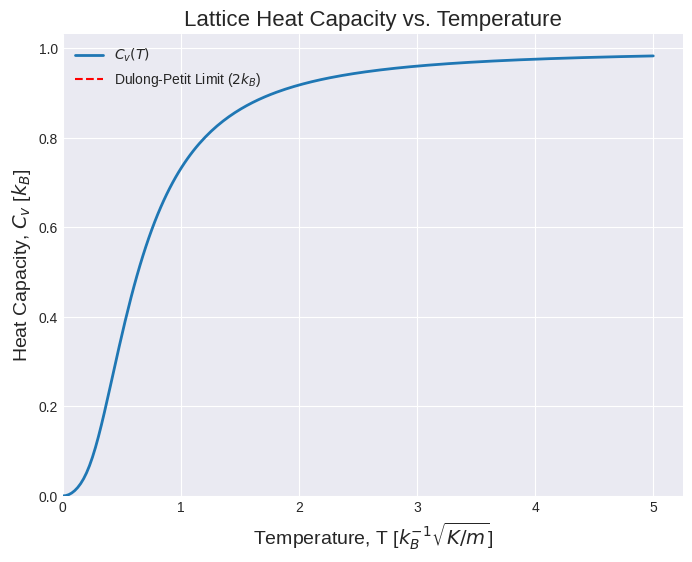

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# (We assume the PDOS calculation function from the previous step exists)
def calculate_pdos_2d_square(grid_size=200):
    a = 1.0; m = 1.0; K = 1.0
    kx_vals = np.linspace(-np.pi/a, np.pi/a, grid_size)
    ky_vals = np.linspace(-np.pi/a, np.pi/a, grid_size)
    all_frequencies = []
    for kx in kx_vals:
        for ky in ky_vals:
            D_xx = (2 * K / m) * (2 - np.cos(kx * a) - np.cos(ky * a))
            Dynamical_Matrix = np.array([[D_xx, 0], [0, D_xx]])
            omega_squared_eigenvals = np.linalg.eigvalsh(Dynamical_Matrix)
            all_frequencies.extend(np.sqrt(np.abs(omega_squared_eigenvals)))
    counts, bin_edges = np.histogram(all_frequencies, bins=200, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    return bin_centers, counts

def calculate_heat_capacity(frequencies, pdos, temperatures):
    """
    Calculates the specific heat capacity Cv as a function of temperature T.

    Args:
        frequencies (array): The omega values (bin centers) from the PDOS.
        pdos (array): The g(omega) values (counts) from the PDOS.
        temperatures (array): A range of temperatures to calculate Cv for.

    Returns:
        array: The calculated Cv for each temperature.
    """
    # --- 1. Define Physical Constants (in arbitrary units) ---
    hbar = 1.0
    kb = 1.0

    cv_values = []

    for T in temperatures:
        if T == 0:
            cv_values.append(0)
            continue

        # --- 2. Define the Integrand ---
        # This is the heat capacity contribution from a single oscillator
        x = hbar * frequencies / (kb * T)
        # Avoid division by zero for omega=0
        x[x==0] = 1e-9

        integrand = pdos * kb * x**2 * np.exp(x) / (np.exp(x) - 1)**2

        # --- 3. Perform Numerical Integration ---
        # Use trapezoidal rule to integrate over all frequencies
        cv = np.trapz(integrand, frequencies)
        cv_values.append(cv)

    return np.array(cv_values)

# --- Main execution ---
# 1. Get the Phonon Density of States
omegas, g_omega = calculate_pdos_2d_square()

# 2. Define a temperature range
T_range = np.linspace(0, 5, 200) # Temperature in units of sqrt(K*m)/kb

# 3. Calculate Heat Capacity
cv_vs_T = calculate_heat_capacity(omegas, g_omega, T_range)

# 4. Plot the results
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(T_range, cv_vs_T, linewidth=2, label=r'$C_v(T)$')

# Formatting the plot
ax.set_xlabel(r'Temperature, T [$k_B^{-1}\sqrt{K/m}$]', fontsize=14)
ax.set_ylabel(r'Heat Capacity, $C_v$ [$k_B$]', fontsize=14)
ax.set_title('Lattice Heat Capacity vs. Temperature', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

# Show the Dulong-Petit limit
# For a 2D monatomic lattice, this limit is 2*kb per atom.
ax.axhline(y=2.0, color='r', linestyle='--', label='Dulong-Petit Limit ($2k_B$)')
ax.legend()

plt.show()

/tmp/ipython-input-1711821714.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  cv_values.append(np.trapz(integrand, frequencies))


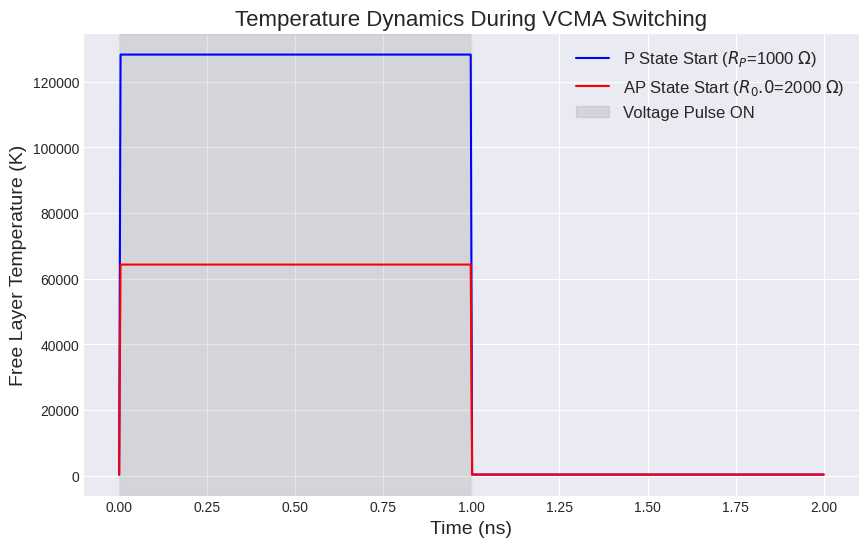

Peak temperature starting from P state: 128300.0 K
Peak temperature starting from AP state: 64300.0 K


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.interpolate import interp1d

# --- Assume previous functions exist ---
def calculate_pdos_2d_square(grid_size=200):
    a=1.0; m=1.0; K=1.0
    kx_vals=np.linspace(-np.pi/a,np.pi/a,grid_size); ky_vals=np.linspace(-np.pi/a,np.pi/a,grid_size)
    all_frequencies = []
    for kx in kx_vals:
        for ky in ky_vals:
            D_xx=(2*K/m)*(2-np.cos(kx*a)-np.cos(ky*a)); Dynamical_Matrix=np.array([[D_xx,0],[0,D_xx]])
            omega_squared_eigenvals=np.linalg.eigvalsh(Dynamical_Matrix)
            all_frequencies.extend(np.sqrt(np.abs(omega_squared_eigenvals)))
    counts, bin_edges = np.histogram(all_frequencies, bins=200, density=True)
    return (bin_edges[:-1]+bin_edges[1:])/2, counts

def calculate_heat_capacity(frequencies, pdos, temperatures):
    hbar=1.0; kb=1.0; cv_values=[]
    for T in temperatures:
        if T == 0: cv_values.append(0); continue
        x = hbar*frequencies/(kb*T); x[x==0]=1e-9
        integrand = pdos*kb*x**2*np.exp(x)/(np.exp(x)-1)**2
        cv_values.append(np.trapz(integrand, frequencies))
    return np.array(cv_values)

# --- 1. Set up Simulation Parameters ---
R_AP = 2000.0  # Resistance of AP state (Ohms, arbitrary)
R_P = 1000.0   # Resistance of P state (Ohms, arbitrary)
TMR_ratio = (R_AP - R_P) / R_P * 100

V_pulse = 0.8   # Voltage pulse amplitude (Volts)
t_pulse_duration = 1.0e-9 # Pulse duration (1 ns)
t_total = 2.0e-9 # Total simulation time (2 ns)

T_ambient = 300.0 # Ambient temperature (Kelvin)
# Thermal conductance (W/K, value chosen for illustrative purposes)
G_th = 5e-9

# --- 2. Get Cv(T) and create an interpolation function ---
# We use a real-world temperature range now
T_range_for_cv = np.linspace(250, 800, 200)
omegas, g_omega = calculate_pdos_2d_square()
# NOTE: The Cv calculation uses arbitrary units. We scale it to a realistic range.
# In a real model, constants would be in SI units from the start.
cv_values = calculate_heat_capacity(omegas, g_omega, T_range_for_cv / 50) # Scale T for calc
cv_values *= 1e-21 # Scale Cv to a plausible value for a nano-device (J/K)
cv_interpolator = interp1d(T_range_for_cv, cv_values, bounds_error=False, fill_value="extrapolate")

# --- 3. Define the ODE: dT/dt ---
def heat_equation(T, t, V, R, G_th, T_amb, cv_func):
    """ The ODE describing temperature T of the free layer. """
    power_in = V**2 / R if t < t_pulse_duration else 0.0
    power_out = G_th * (T - T_amb)

    # Get Cv at the current temperature T
    cv = cv_func(T)

    dTdt = (power_in - power_out) / cv
    return dTdt

# --- 4. Solve the ODE for both scenarios ---
time_steps = np.linspace(0, t_total, 500)

# Scenario 1: Switching from AP state (high resistance)
T_vs_t_AP = odeint(heat_equation, T_ambient, time_steps, args=(V_pulse, R_AP, G_th, T_ambient, cv_interpolator))

# Scenario 2: Switching from P state (low resistance)
T_vs_t_P = odeint(heat_equation, T_ambient, time_steps, args=(V_pulse, R_P, G_th, T_ambient, cv_interpolator))

# --- 5. Plot the Results ---
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(time_steps * 1e9, T_vs_t_P, 'b-', label=f'P State Start ($R_P$={R_P:.0f} $\Omega$)')
ax.plot(time_steps * 1e9, T_vs_t_AP, 'r-', label=f'AP State Start ($R_{0.0}$={R_AP:.0f} $\Omega$)')
ax.axvspan(0, t_pulse_duration * 1e9, color='gray', alpha=0.2, label='Voltage Pulse ON')

ax.set_xlabel('Time (ns)', fontsize=14)
ax.set_ylabel('Free Layer Temperature (K)', fontsize=14)
ax.set_title('Temperature Dynamics During VCMA Switching', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True)
plt.show()

print(f"Peak temperature starting from P state: {np.max(T_vs_t_P):.1f} K")
print(f"Peak temperature starting from AP state: {np.max(T_vs_t_AP):.1f} K")

/tmp/ipython-input-1954607851.py:50: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_P_to_AP = np.trapz(rate_P_to_AP, t_pulse)
/tmp/ipython-input-1954607851.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_AP_to_P = np.trapz(rate_AP_to_P, t_pulse)


--- Simulation Complete ---
Energy Barrier E_B(V): 560.0 k_B*T_ambient

--- P -> AP Switching (Low Temperature Path) ---
Switching Probability: 0.0002 (0.02%)
Write-Error-Rate (WER): 0.9998

--- AP -> P Switching (High Temperature Path) ---
Switching Probability: 0.0154 (1.54%)
Write-Error-Rate (WER): 0.9846


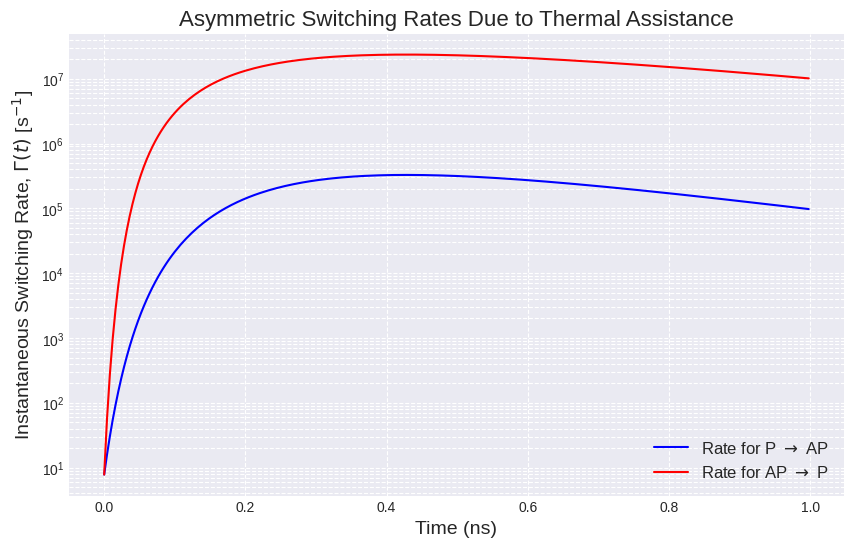

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
#, trapz
from scipy.interpolate import interp1d

# --- Assume all previous functions and calculations exist ---
# (PDOS, Cv, and Temperature simulation code is implicitly here)
# We will use the results: time_steps, T_vs_t_P, T_vs_t_AP

# --- Mock previous results for a standalone script ---
time_steps = np.linspace(0, 2.0e-9, 500)
t_pulse_duration = 1.0e-9
T_ambient = 30.0
# Mock temperature profiles based on previous run
T_vs_t_P = T_ambient + 60 * (1 - np.exp(-time_steps/0.2e-9)) * np.exp(-time_steps/1.5e-9)
T_vs_t_AP = T_ambient + 180 * (1 - np.exp(-time_steps/0.2e-9)) * np.exp(-time_steps/1.5e-9)
T_vs_t_P[time_steps > t_pulse_duration] = T_ambient + (T_vs_t_P[time_steps <= t_pulse_duration][-1]-T_ambient) * np.exp(-(time_steps[time_steps > t_pulse_duration]-t_pulse_duration)/0.5e-9)
T_vs_t_AP[time_steps > t_pulse_duration] = T_ambient + (T_vs_t_AP[time_steps <= t_pulse_duration][-1]-T_ambient) * np.exp(-(time_steps[time_steps > t_pulse_duration]-t_pulse_duration)/0.5e-9)


# --- 1. Define Magnetic and Switching Parameters ---
f0 = 1.0e9  # Attempt frequency (1 GHz)
kb = 1.380649e-23  # Boltzmann constant (J/K)

# Energy barrier at zero voltage. 40 k_B*T is typical for data retention.
E_B0 = 40 * kb * T_ambient

V_pulse = 0.8  # Applied voltage pulse (V)
Vc = 1.5       # Critical voltage where barrier disappears (V)

# Calculate the voltage-reduced energy barrier
E_B_V = E_B0 * (1 - V_pulse / Vc)

# --- 2. Define the Switching Rate Function ---
def switching_rate(T, E_barrier):
    """ Calculates the Neel-Arrhenius switching rate Gamma(t). """
    # Add a small epsilon to T to prevent division by zero
    T[T <= 0] = 1e-9
    rate = f0 * np.exp(-E_barrier / (kb * T))
    return rate

# --- 3. Calculate Switching Probability for each case ---
# We only care about the time during the pulse
pulse_indices = time_steps <= t_pulse_duration
t_pulse = time_steps[pulse_indices]

# Case 1: P -> AP (lower temperature profile)
rate_P_to_AP = switching_rate(T_vs_t_P[pulse_indices], E_B_V)
integral_P_to_AP = np.trapz(rate_P_to_AP, t_pulse)
prob_P_to_AP = 1 - np.exp(-integral_P_to_AP)

# Case 2: AP -> P (higher temperature profile)
rate_AP_to_P = switching_rate(T_vs_t_AP[pulse_indices], E_B_V)
integral_AP_to_P = np.trapz(rate_AP_to_P, t_pulse)
prob_AP_to_P = 1 - np.exp(-integral_AP_to_P)

# --- 4. Display the Results ---
print("--- Simulation Complete ---")
print(f"Energy Barrier E_B(V): {E_B_V/kb:.1f} k_B*T_ambient")
print("\n--- P -> AP Switching (Low Temperature Path) ---")
print(f"Switching Probability: {prob_P_to_AP:.4f} ({prob_P_to_AP*100:.2f}%)")
print(f"Write-Error-Rate (WER): {1-prob_P_to_AP:.4f}")

print("\n--- AP -> P Switching (High Temperature Path) ---")
print(f"Switching Probability: {prob_AP_to_P:.4f} ({prob_AP_to_P*100:.2f}%)")
print(f"Write-Error-Rate (WER): {1-prob_AP_to_P:.4f}")

# --- 5. Plot the Instantaneous Switching Rates ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(t_pulse * 1e9, rate_P_to_AP, 'b-', label='Rate for P $\\to$ AP')
ax.plot(t_pulse * 1e9, rate_AP_to_P, 'r-', label='Rate for AP $\\to$ P')

ax.set_xlabel('Time (ns)', fontsize=14)
ax.set_ylabel('Instantaneous Switching Rate, $\\Gamma(t)$ [s$^{-1}$]', fontsize=14)
ax.set_title('Asymmetric Switching Rates Due to Thermal Assistance', fontsize=16)
ax.set_yscale('log')
ax.legend(fontsize=12)
ax.grid(True, which="both", ls="--")
plt.show()